In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
events = pd.read_csv('rr_data/events.csv')
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [19]:
from datetime import datetime

import datetime

def unix_to_datetime(timestamp):
    try:
        # If timestamp is in milliseconds, convert to seconds
        if timestamp > 1e12:
            timestamp /= 1000
        dt_object = datetime.datetime.fromtimestamp(timestamp)
        return dt_object
    except (OSError, OverflowError, ValueError) as e:
        print(f"Invalid timestamp: {e}")
        return None

#[unix_to_datetime(timestamp) for timestamp in events['timestamp'].head()]
events['datetime'] = [unix_to_datetime(timestamp) for timestamp in events['timestamp']]

In [20]:
events['month'] = events['datetime'].dt.month
events['date'] = events['datetime'].dt.date
events =events.sort_values('datetime').reset_index(drop=True)

In [ ]:
#events.describe()

,timestamp,visitorid,itemid,transactionid,datetime,month
count,2.756101e+06,2.756101e+06,2.756101e+06,22457.000000,2756101,2.756101e+06
mean,1.436424e+12,7.019229e+05,2.349225e+05,8826.497796,2015-07-09 02:48:08.348103936,6.765305e+00
min,1.430622e+12,0.000000e+00,3.000000e+00,0.000000,2015-05-02 23:00:04.384000,5.000000e+00
25%,1.433478e+12,3.505660e+05,1.181200e+05,4411.000000,2015-06-05 00:23:14.792000,6.000000e+00
50%,1.436453e+12,7.020600e+05,2.360670e+05,8813.000000,2015-07-09 10:43:33.599000064,7.000000e+00
75%,1.439225e+12,1.053437e+06,3.507150e+05,13224.000000,2015-08-10 12:45:05.168000,8.000000e+00
max,1.442545e+12,1.407579e+06,4.668670e+05,17671.000000,2015-09-17 22:59:47.788000,9.000000e+00
std,3.366312e+09,4.056875e+05,1.341954e+05,5098.996290,NaN,1.290864e+00


In [21]:
vcounts = events['visitorid'].value_counts()
icounts = events['itemid'].value_counts()

In [22]:
#interaction_distribution = vcounts.value_counts()
interaction_distribution = icounts.value_counts()

interaction_distribution.cumsum()/interaction_distribution.sum()


count
1       0.313149
2       0.461319
3       0.550951
4       0.613088
5       0.658395
          ...   
534     0.999983
540     0.999987
541     0.999991
542     0.999996
3412    1.000000
Name: count, Length: 601, dtype: float64

In [23]:
## filter out users with less than k interactions

def get_id_filter(events, id_column, k):
    counts = events[id_column].value_counts()
    keep_ids = counts[counts > k].index
    return keep_ids




In [25]:
from copy import deepcopy

temp_e = deepcopy(events)

ulist = get_id_filter(temp_e,'visitorid', 3)
ilist = get_id_filter(temp_e,'itemid', 3)

temp_e = temp_e[temp_e['visitorid'].isin(ulist)]
temp_e = temp_e[temp_e['itemid'].isin(ulist)]

temp_e.shape

(91863, 8)

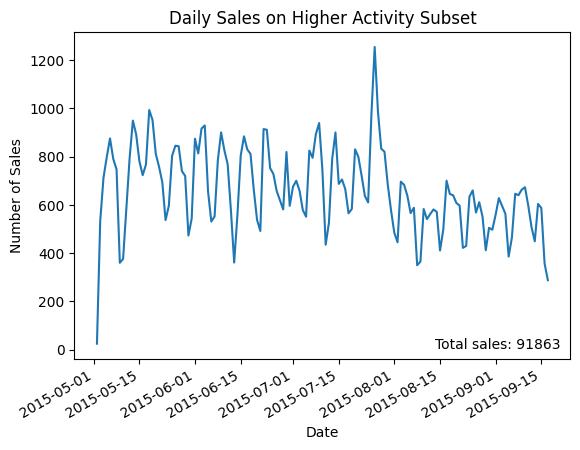

In [31]:
# plot daily number of sales

daily_sales = temp_e['date'].value_counts().sort_index()

fig, ax = plt.subplots()
plt.title('Daily Sales on Higher Activity Subset')
ax.plot(daily_sales.index, daily_sales.values)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Sales')
# rotate and align the tick labels so they look better
fig.autofmt_xdate()
# footnote with the total number of sales
ax.text(0.98, 0.02, f"Total sales: {daily_sales.sum()}", transform=ax.transAxes, ha='right', va='bottom', fontsize=10)
plt.show()